# Chirp visualization

This notebook plots a leading-order **Newtonian quadrupole** inspiral chirp.

- Strain $h$ is dimensionless ($\Delta L / L$).
- Merger is at $t = 0$; times before merger are negative.
- Scope: circular, non-spinning, inspiral-only (no merger/ringdown, spin, or PN).

Install once from the repo root: `pip install -e ".[dev]"`.


In [1]:
import matplotlib.pyplot as plt

from chirp_gen import BinaryParameters, WaveformConfig, generate_waveform


## GW150914-like inspiral

Approximate published values: $m_1=36\,M_\odot$, $m_2=29\,M_\odot$, $d_L=410\,\mathrm{Mpc}$, band $35$–$250\,\mathrm{Hz}$.


In [2]:
params = BinaryParameters(
    m1_msun=36.0,
    m2_msun=29.0,
    distance_mpc=410.0,
    f_start_hz=35.0,
    f_end_hz=250.0,
)
config = WaveformConfig(sample_rate_hz=4096.0)
result = generate_waveform(params, config)

print(f"samples: {len(result.time_s)}")
print(f"M_c [kg]: {result.metadata['M_c_kg']:.3e}")
print(f"eta: {result.metadata['eta']:.4f}")


samples: 775
M_c [kg]: 5.588e+31
eta: 0.2471


### Strain and frequency vs time

Toward merger ($t \to 0$) the wave should get **faster** and **louder**.


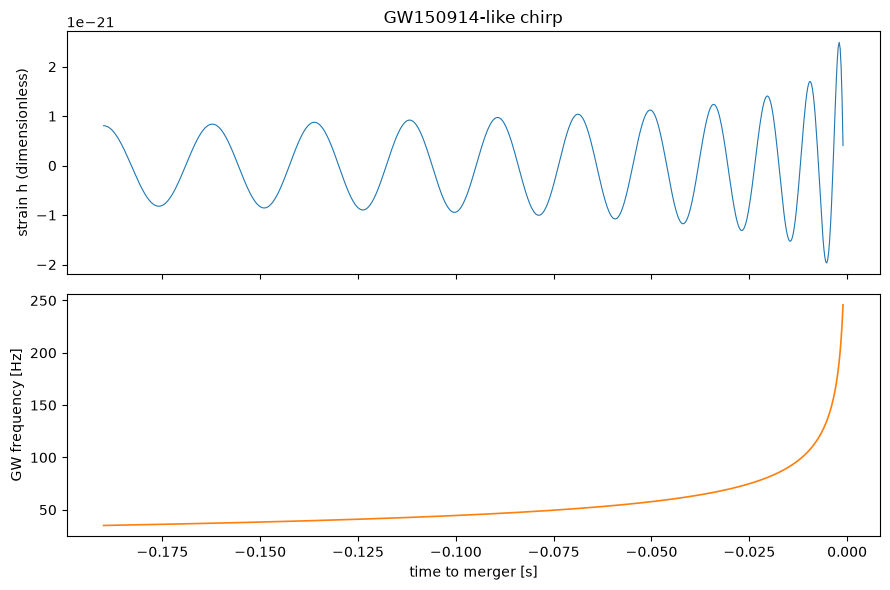

In [3]:
fig, (ax_h, ax_f) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax_h.plot(result.time_s, result.strain, color="C0", lw=0.8)
ax_h.set_ylabel("strain h (dimensionless)")
ax_h.set_title("GW150914-like chirp")

ax_f.plot(result.time_s, result.frequency_hz, color="C1", lw=1.2)
ax_f.set_xlabel("time to merger [s]")
ax_f.set_ylabel("GW frequency [Hz]")

fig.tight_layout()
plt.show()


## Chirp-mass comparison

Same frequency band and distance; equal-mass binaries with different total mass
(hence different chirp mass). Larger $M_c$ sweeps the band in less time.


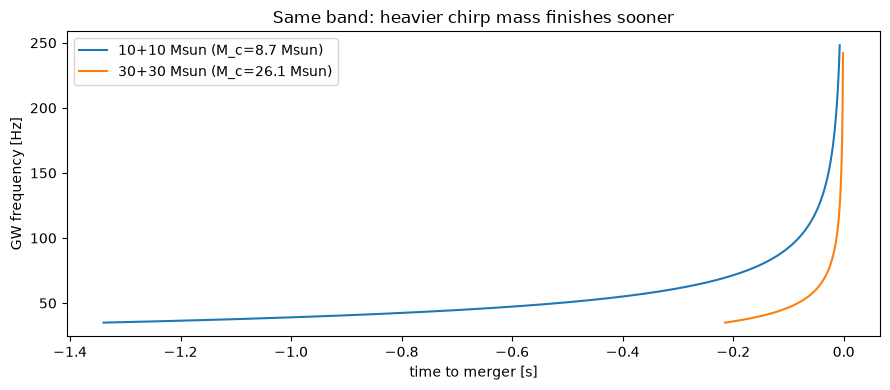

light duration: 1.332 s
heavy duration: 0.213 s


In [4]:
light = generate_waveform(
    BinaryParameters(
        m1_msun=10.0,
        m2_msun=10.0,
        distance_mpc=410.0,
        f_start_hz=35.0,
        f_end_hz=250.0,
    ),
    config,
)
heavy = generate_waveform(
    BinaryParameters(
        m1_msun=30.0,
        m2_msun=30.0,
        distance_mpc=410.0,
        f_start_hz=35.0,
        f_end_hz=250.0,
    ),
    config,
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    light.time_s,
    light.frequency_hz,
    label=f"10+10 Msun (M_c={light.metadata['M_c_kg']/1.989e30:.1f} Msun)",
)
ax.plot(
    heavy.time_s,
    heavy.frequency_hz,
    label=f"30+30 Msun (M_c={heavy.metadata['M_c_kg']/1.989e30:.1f} Msun)",
)
ax.set_xlabel("time to merger [s]")
ax.set_ylabel("GW frequency [Hz]")
ax.set_title("Same band: heavier chirp mass finishes sooner")
ax.legend()
fig.tight_layout()
plt.show()

print(f"light duration: {light.time_s[-1] - light.time_s[0]:.3f} s")
print(f"heavy duration: {heavy.time_s[-1] - heavy.time_s[0]:.3f} s")


## Limits and next steps

This MVP is **inspiral-only**: no merger, ringdown, spin, eccentricity, or post-Newtonian corrections.

To save a waveform from the terminal (GW150914 defaults):

```bash
chirp-gen -o out/gw150914.npz
```
